# Proyek Akhir Sains Data
# Model Artificial Neural Network (ANN) Untuk Klasifikasi Pengidap Chronic Kidney Disease (CKD) Berdasarkan Data Medis Tubuh Pasien
## Kelompok 3
1. Rifki Prakasya
2. Muhamad Hafizh
3. Ariya Puttasa Suwarno
4. Muhammad Ghofara Revonanda


# Import Module

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

import tensorflow as tf

# Load Dataset

In [ ]:
df = pd.read_csv('kidney_disease.csv')
df

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51,7200,5.9,no,no,no,good,no,no,notckd


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [ ]:
df.describe()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


#Preprocessing Data

In [ ]:
#hapus kolom/fitur id secara permanen
df.drop(['id'], axis = 1, inplace = True)

## Dealing with Abnormal Values

In [ ]:
#cek nilai unik tiap kolom/fitur
#untuk mengecek apakah ada abnormal values, seperti typo
for i in df.columns:
  print("------------------------------------------------",i,"-------------------------------------------------------")
  print('\n')
  print(df[i].unique().tolist())

------------------------------------------------ age -------------------------------------------------------


[48.0, 7.0, 62.0, 51.0, 60.0, 68.0, 24.0, 52.0, 53.0, 50.0, 63.0, 40.0, 47.0, 61.0, 21.0, 42.0, 75.0, 69.0, nan, 73.0, 70.0, 65.0, 76.0, 72.0, 82.0, 46.0, 45.0, 35.0, 54.0, 11.0, 59.0, 67.0, 15.0, 55.0, 44.0, 26.0, 64.0, 56.0, 5.0, 74.0, 38.0, 58.0, 71.0, 34.0, 17.0, 12.0, 43.0, 41.0, 57.0, 8.0, 39.0, 66.0, 81.0, 14.0, 27.0, 83.0, 30.0, 4.0, 3.0, 6.0, 32.0, 80.0, 49.0, 90.0, 78.0, 19.0, 2.0, 33.0, 36.0, 37.0, 23.0, 25.0, 20.0, 29.0, 28.0, 22.0, 79.0]
------------------------------------------------ bp -------------------------------------------------------


[80.0, 50.0, 70.0, 90.0, nan, 100.0, 60.0, 110.0, 140.0, 180.0, 120.0]
------------------------------------------------ sg -------------------------------------------------------


[1.02, 1.01, 1.005, 1.015, nan, 1.025]
------------------------------------------------ al ----------------------------------------------------

In [ ]:
#dealing with abormally values
#perhatikan bahwa dari output di atas
#terdapat typo pada beberapa kolom/fitur
df = df.replace({'\t':np.nan , '\t43':43,'\t6200':6200 , '\t8400':8400, '\t?':np.nan,'ckd\t':"ckd","\tyes":"yes","\tno":"no"," yes":"yes"})

In [ ]:
#cek kembali
for i in df.columns:
  print("------------------------------------------------",i,"-------------------------------------------------------")
  print('\n')
  print(df[i].unique().tolist())

------------------------------------------------ age -------------------------------------------------------


[48.0, 7.0, 62.0, 51.0, 60.0, 68.0, 24.0, 52.0, 53.0, 50.0, 63.0, 40.0, 47.0, 61.0, 21.0, 42.0, 75.0, 69.0, nan, 73.0, 70.0, 65.0, 76.0, 72.0, 82.0, 46.0, 45.0, 35.0, 54.0, 11.0, 59.0, 67.0, 15.0, 55.0, 44.0, 26.0, 64.0, 56.0, 5.0, 74.0, 38.0, 58.0, 71.0, 34.0, 17.0, 12.0, 43.0, 41.0, 57.0, 8.0, 39.0, 66.0, 81.0, 14.0, 27.0, 83.0, 30.0, 4.0, 3.0, 6.0, 32.0, 80.0, 49.0, 90.0, 78.0, 19.0, 2.0, 33.0, 36.0, 37.0, 23.0, 25.0, 20.0, 29.0, 28.0, 22.0, 79.0]
------------------------------------------------ bp -------------------------------------------------------


[80.0, 50.0, 70.0, 90.0, nan, 100.0, 60.0, 110.0, 140.0, 180.0, 120.0]
------------------------------------------------ sg -------------------------------------------------------


[1.02, 1.01, 1.005, 1.015, nan, 1.025]
------------------------------------------------ al ----------------------------------------------------

##Dealing with Missing Values

In [ ]:
#cek jumlah missing value untuk setiap kolom/fitur
df.isna().sum()

age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [ ]:
#dealing with missing value
#akan dilakukan imputasi dengan modus
df = df.fillna(df.mode().iloc[0])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             400 non-null    float64
 1   bp              400 non-null    float64
 2   sg              400 non-null    float64
 3   al              400 non-null    float64
 4   su              400 non-null    float64
 5   rbc             400 non-null    object 
 6   pc              400 non-null    object 
 7   pcc             400 non-null    object 
 8   ba              400 non-null    object 
 9   bgr             400 non-null    float64
 10  bu              400 non-null    float64
 11  sc              400 non-null    float64
 12  sod             400 non-null    float64
 13  pot             400 non-null    float64
 14  hemo            400 non-null    float64
 15  pcv             400 non-null    object 
 16  wc              400 non-null    object 
 17  rc              400 non-null    obj

In [ ]:
#melihat jumlah nilai pada tiap kolom dengan tipe data object
for i in df.select_dtypes(exclude="float").columns:
  print(df[i].value_counts())
  print(50*'=')

normal      353
abnormal     47
Name: rbc, dtype: int64
normal      324
abnormal     76
Name: pc, dtype: int64
notpresent    358
present        42
Name: pcc, dtype: int64
notpresent    378
present        22
Name: ba, dtype: int64
41    92
52    21
44    19
48    19
40    16
43    14
45    13
42    13
33    12
50    12
32    12
36    12
28    12
37    11
34    11
35     9
29     9
46     9
30     9
31     8
24     7
39     7
26     6
38     5
51     4
53     4
49     4
47     4
54     4
25     3
22     3
27     3
19     2
23     2
15     1
21     1
20     1
43     1
17     1
9      1
18     1
16     1
14     1
Name: pcv, dtype: int64
9800     117
6700      10
9200       9
9600       9
7200       9
        ... 
11200      1
19100      1
12300      1
12700      1
16700      1
Name: wc, Length: 91, dtype: int64
5.2    149
4.5     16
4.9     14
4.7     11
4.8     10
3.9     10
4.6      9
3.4      9
5.9      8
5.5      8
6.1      8
5.0      8
3.7      8
5.3      7
5.8      7
5.4      7
3.8  

In [ ]:
#perhatikan bahwa ada kesalahan tipe data dari kolom/atribut pcv, wc, dan rc
#yang seharusnya merupakan tipe data numerik
#sehingga perlu dikonversi menjadi numerik
df['pcv'] = df['pcv'].astype(float)
df['wc'] = df['wc'].astype(float)
df['rc'] = df['rc'].astype(float)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             400 non-null    float64
 1   bp              400 non-null    float64
 2   sg              400 non-null    float64
 3   al              400 non-null    float64
 4   su              400 non-null    float64
 5   rbc             400 non-null    object 
 6   pc              400 non-null    object 
 7   pcc             400 non-null    object 
 8   ba              400 non-null    object 
 9   bgr             400 non-null    float64
 10  bu              400 non-null    float64
 11  sc              400 non-null    float64
 12  sod             400 non-null    float64
 13  pot             400 non-null    float64
 14  hemo            400 non-null    float64
 15  pcv             400 non-null    float64
 16  wc              400 non-null    float64
 17  rc              400 non-null    flo

## Encoding Data Kategorik

In [ ]:
#kemudian akan dilakukan encoding untuk atribut dengan tipe data kategorik
#dengan ketentuan:
#1 jika merupakan ckd dan gejala ckd
#0 jika merupakan notckd dan bukan gejala ckd

df['classification'].replace(('notckd', 'ckd'), (0, 1), inplace = True)
df['rbc'].replace(('normal', 'abnormal'), (0, 1), inplace = True)
df['pc'].replace(('normal', 'abnormal'), (0, 1), inplace = True)
df['pcc'].replace(('notpresent', 'present'), (0, 1), inplace = True)
df['ba'].replace(('notpresent', 'present'), (0, 1), inplace = True)
df['htn'].replace(('no', 'yes'), (0, 1), inplace = True)
df['dm'].replace(('no', 'yes'), (0, 1), inplace = True)
df['cad'].replace(('no', 'yes'), (0, 1), inplace = True)
df['appet'].replace(('good', 'poor'), (0, 1), inplace = True)
df['pe'].replace(('no', 'yes'), (0, 1), inplace = True)
df['ane'].replace(('no', 'yes'), (0, 1), inplace = True)

In [ ]:
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,0,0,0,0,121.0,...,44.0,7800.0,5.2,1,1,0,0,0,0,1
1,7.0,50.0,1.020,4.0,0.0,0,0,0,0,99.0,...,38.0,6000.0,5.2,0,0,0,0,0,0,1
2,62.0,80.0,1.010,2.0,3.0,0,0,0,0,423.0,...,31.0,7500.0,5.2,0,1,0,1,0,1,1
3,48.0,70.0,1.005,4.0,0.0,0,1,1,0,117.0,...,32.0,6700.0,3.9,1,0,0,1,1,1,1
4,51.0,80.0,1.010,2.0,0.0,0,0,0,0,106.0,...,35.0,7300.0,4.6,0,0,0,0,0,0,1


##Visualisasi Data

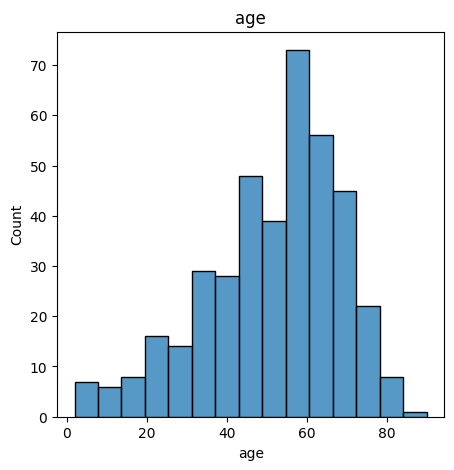

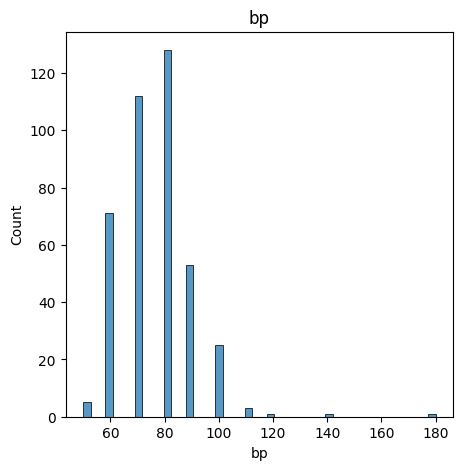

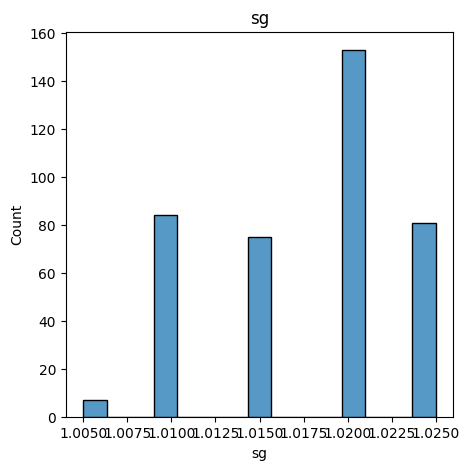

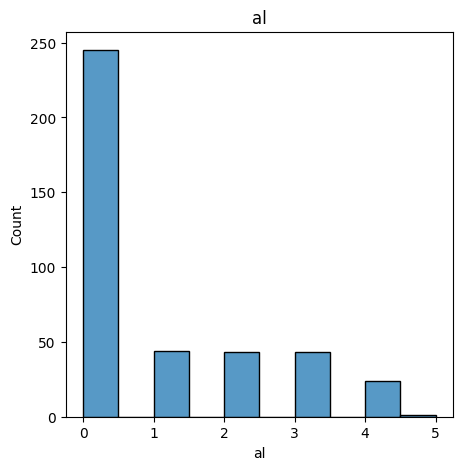

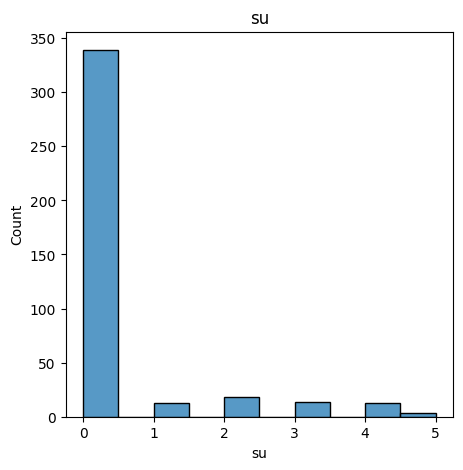

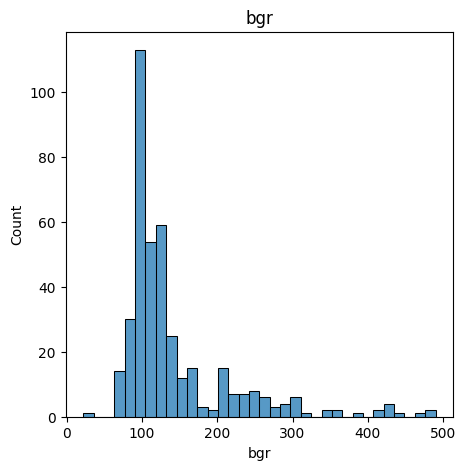

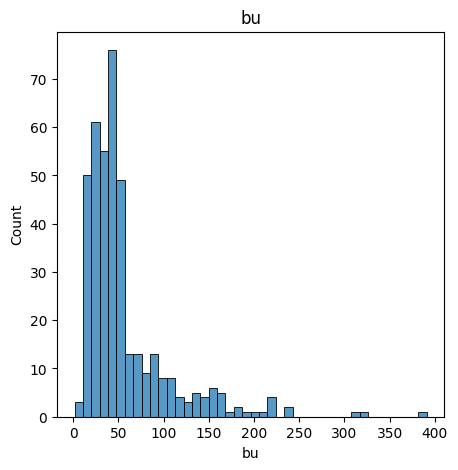

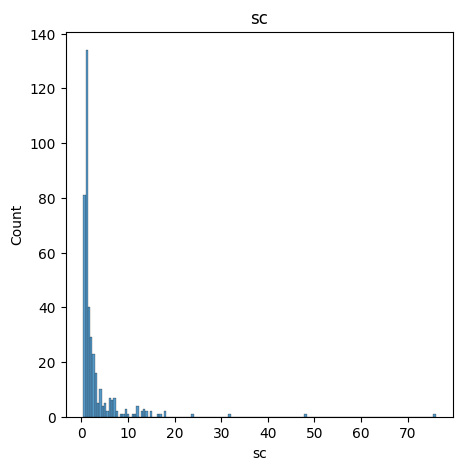

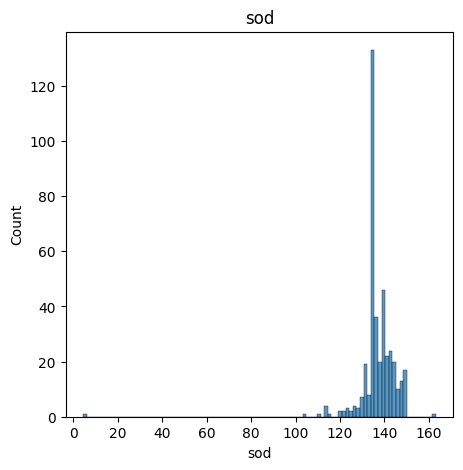

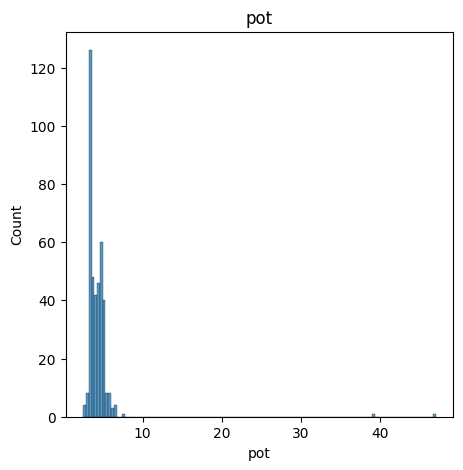

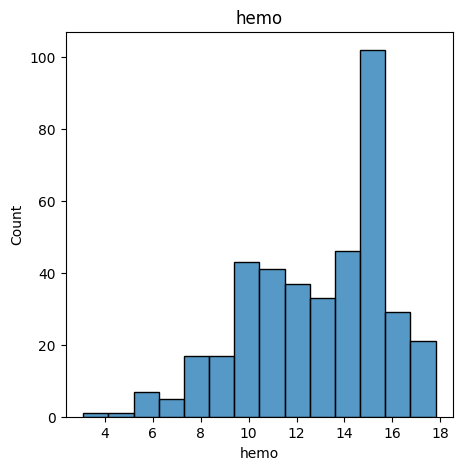

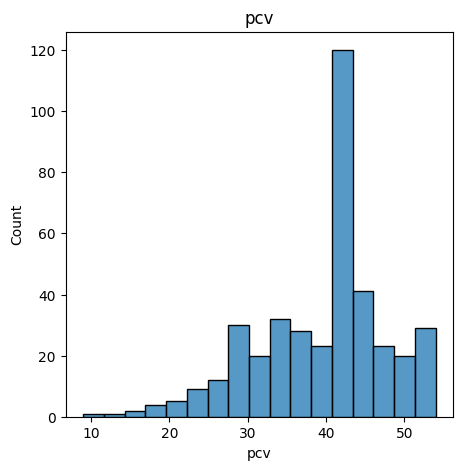

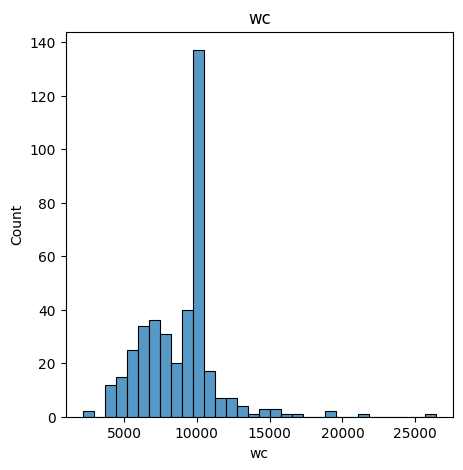

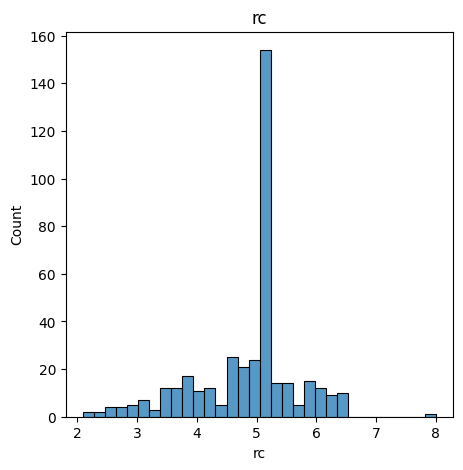

In [ ]:
#melihat histogram dari fitur numerik
num = ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
for i in num:
  plt.figure(figsize = (5,5))
  gph = sns.histplot(df[i])
  gph.set_title(i)
  plt.show

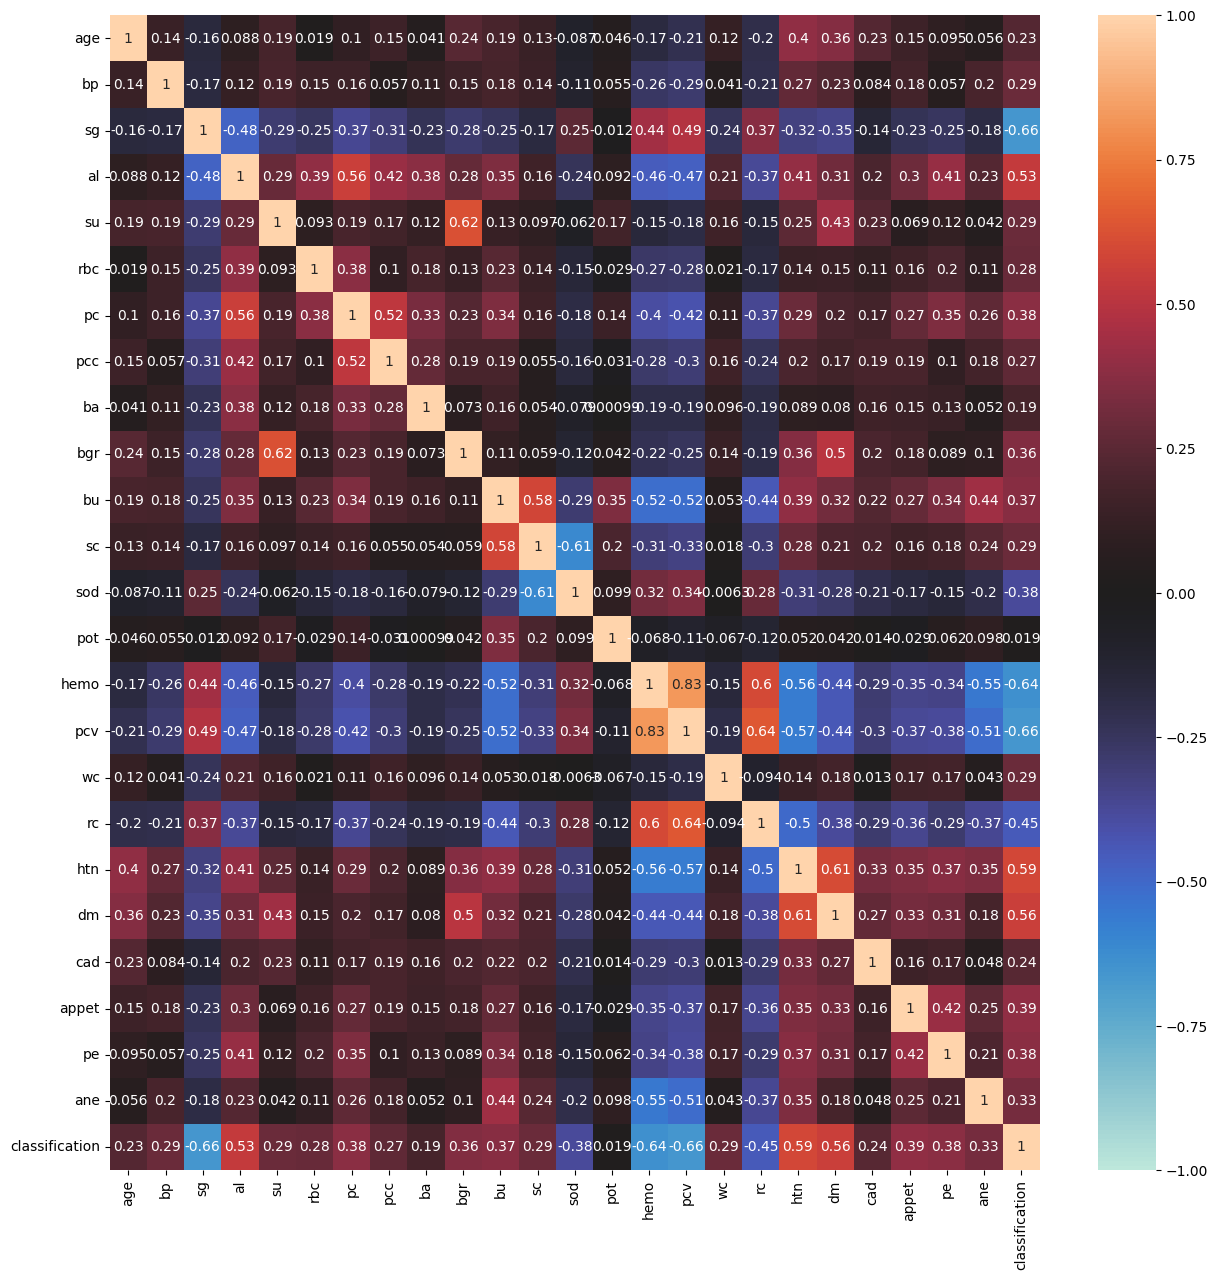

In [ ]:
#melihat korelasi data
corr = df.corr()
plt.subplots(figsize=(15,15))
sns.heatmap(corr, vmin=-1, center=0, vmax=1, annot=True)
plt.show()

## Scaling Data

In [ ]:
sc = MinMaxScaler()

X = df.drop(['classification'], axis = 1)
y = df['classification']

In [ ]:
X

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane
0,48.0,80.0,1.020,1.0,0.0,0,0,0,0,121.0,...,15.4,44.0,7800.0,5.2,1,1,0,0,0,0
1,7.0,50.0,1.020,4.0,0.0,0,0,0,0,99.0,...,11.3,38.0,6000.0,5.2,0,0,0,0,0,0
2,62.0,80.0,1.010,2.0,3.0,0,0,0,0,423.0,...,9.6,31.0,7500.0,5.2,0,1,0,1,0,1
3,48.0,70.0,1.005,4.0,0.0,0,1,1,0,117.0,...,11.2,32.0,6700.0,3.9,1,0,0,1,1,1
4,51.0,80.0,1.010,2.0,0.0,0,0,0,0,106.0,...,11.6,35.0,7300.0,4.6,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,0,0,0,0,140.0,...,15.7,47.0,6700.0,4.9,0,0,0,0,0,0
396,42.0,70.0,1.025,0.0,0.0,0,0,0,0,75.0,...,16.5,54.0,7800.0,6.2,0,0,0,0,0,0
397,12.0,80.0,1.020,0.0,0.0,0,0,0,0,100.0,...,15.8,49.0,6600.0,5.4,0,0,0,0,0,0
398,17.0,60.0,1.025,0.0,0.0,0,0,0,0,114.0,...,14.2,51.0,7200.0,5.9,0,0,0,0,0,0


In [ ]:
y

0      1
1      1
2      1
3      1
4      1
      ..
395    0
396    0
397    0
398    0
399    0
Name: classification, Length: 400, dtype: int64

In [ ]:
X = sc.fit_transform(X.to_numpy())

In [ ]:
X = pd.DataFrame(X, columns = ['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc',
                               'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv',
                               'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane'])

In [ ]:
X

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane
0,0.522727,0.230769,0.75,0.2,0.0,0.0,0.0,0.0,0.0,0.211538,...,0.836735,0.777778,0.231405,0.525424,1.0,1.0,0.0,0.0,0.0,0.0
1,0.056818,0.000000,0.75,0.8,0.0,0.0,0.0,0.0,0.0,0.164530,...,0.557823,0.644444,0.157025,0.525424,0.0,0.0,0.0,0.0,0.0,0.0
2,0.681818,0.230769,0.25,0.4,0.6,0.0,0.0,0.0,0.0,0.856838,...,0.442177,0.488889,0.219008,0.525424,0.0,1.0,0.0,1.0,0.0,1.0
3,0.522727,0.153846,0.00,0.8,0.0,0.0,1.0,1.0,0.0,0.202991,...,0.551020,0.511111,0.185950,0.305085,1.0,0.0,0.0,1.0,1.0,1.0
4,0.556818,0.230769,0.25,0.4,0.0,0.0,0.0,0.0,0.0,0.179487,...,0.578231,0.577778,0.210744,0.423729,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.602273,0.230769,0.75,0.0,0.0,0.0,0.0,0.0,0.0,0.252137,...,0.857143,0.844444,0.185950,0.474576,0.0,0.0,0.0,0.0,0.0,0.0
396,0.454545,0.153846,1.00,0.0,0.0,0.0,0.0,0.0,0.0,0.113248,...,0.911565,1.000000,0.231405,0.694915,0.0,0.0,0.0,0.0,0.0,0.0
397,0.113636,0.230769,0.75,0.0,0.0,0.0,0.0,0.0,0.0,0.166667,...,0.863946,0.888889,0.181818,0.559322,0.0,0.0,0.0,0.0,0.0,0.0
398,0.170455,0.076923,1.00,0.0,0.0,0.0,0.0,0.0,0.0,0.196581,...,0.755102,0.933333,0.206612,0.644068,0.0,0.0,0.0,0.0,0.0,0.0


# Detecting and Handling Outlier (Gausah dimasukkin)

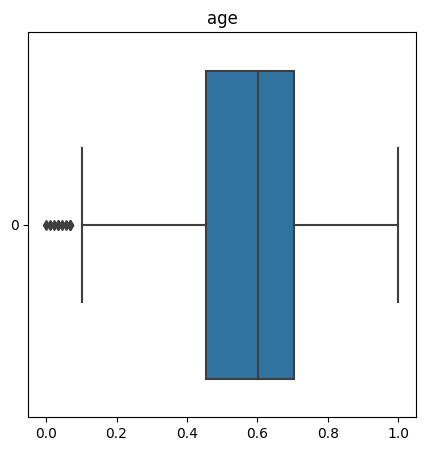

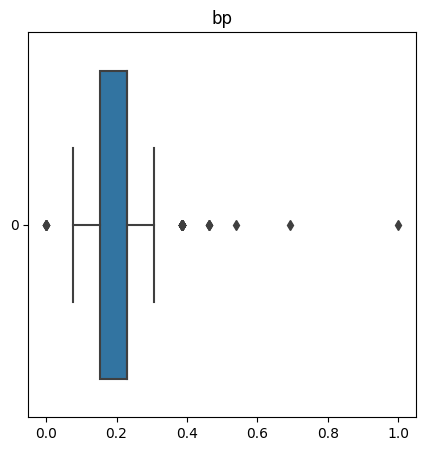

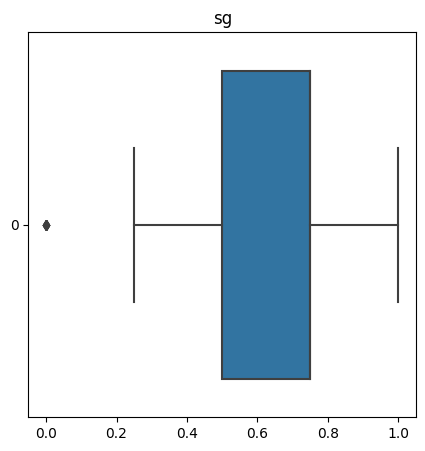

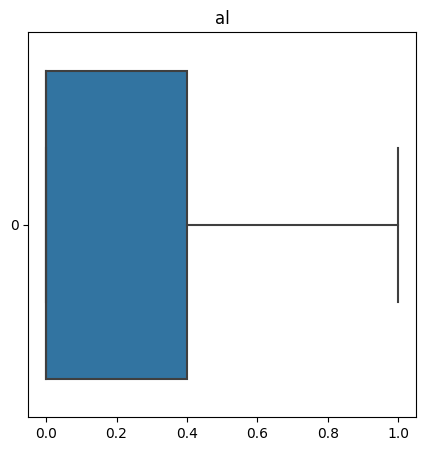

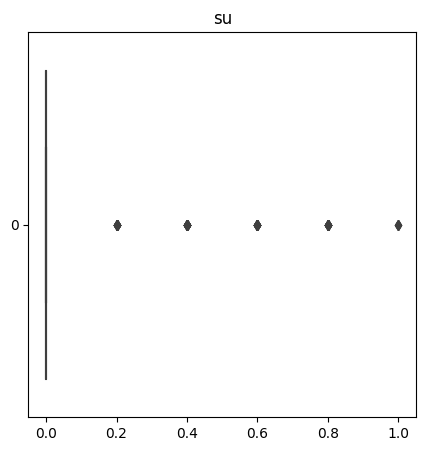

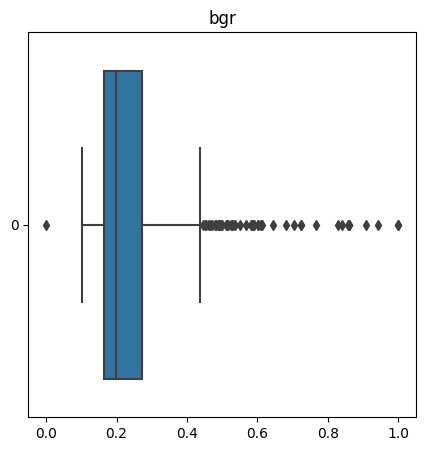

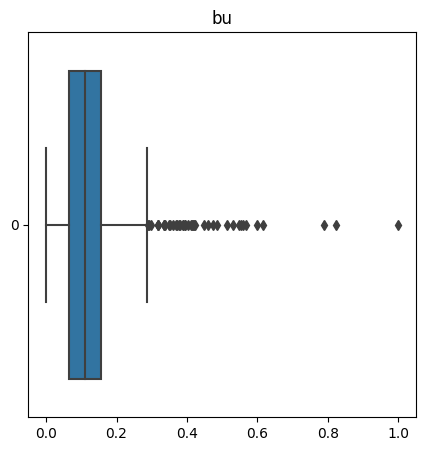

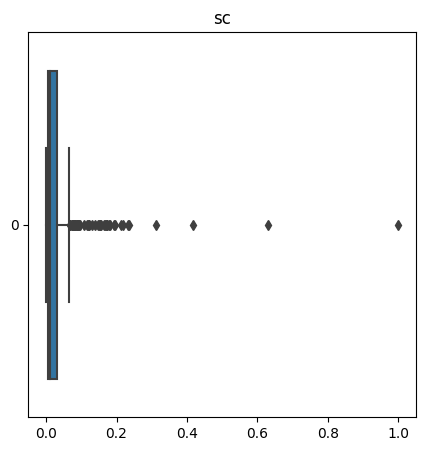

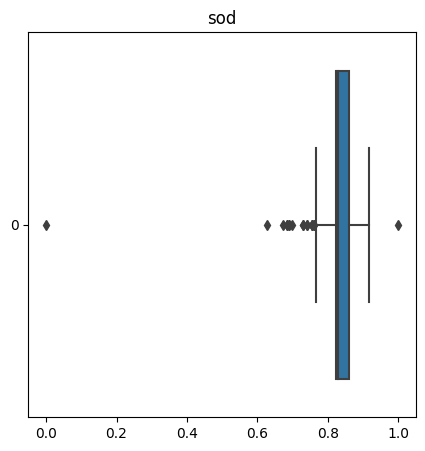

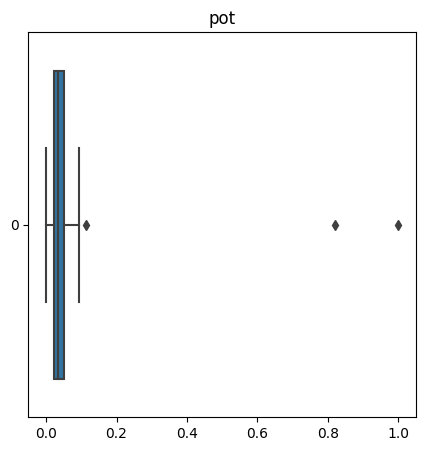

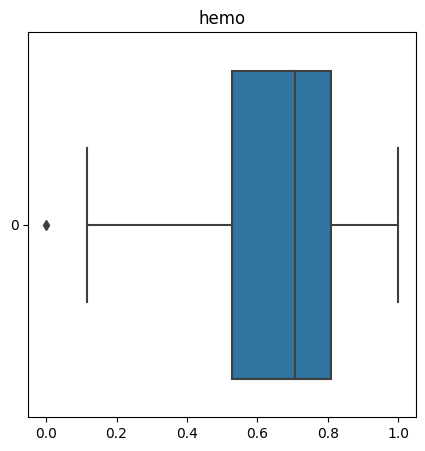

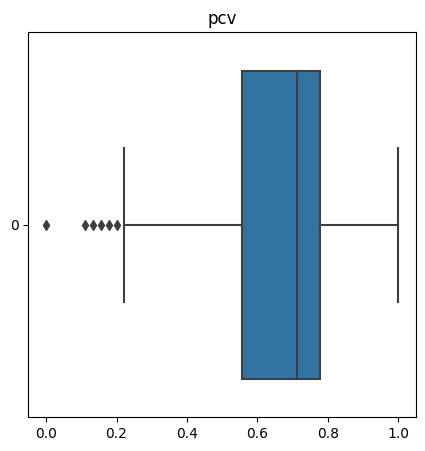

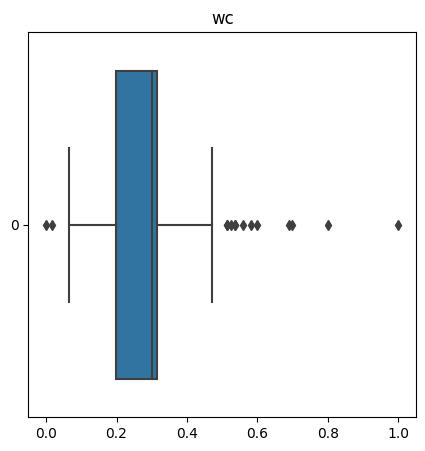

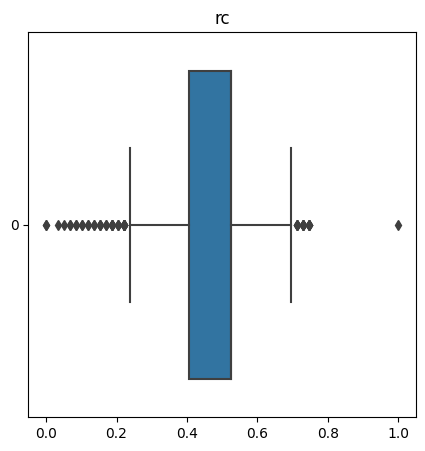

In [ ]:
#melihat outliers dengan menggunakan visualisasi boxplot
num = ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']

for i in num:
  plt.figure(figsize = (5,5))
  gph = sns.boxplot(X[i], orient = 'h')
  gph.set_title(i)
  plt.show

In [ ]:
#mendeteksi outliers dengan pendekatan IQR
def outliers(df, ft):
  Q1 = df[ft].quantile(0.25)
  Q3 = df[ft].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5*IQR
  upper_bound = Q3 + 1.5*IQR

  ls = df.index[(df[ft] < lower_bound) | (df[ft] > upper_bound)]
  return ls

outlier_index = []
for i in num:
  outlier_index.extend(outliers(X, i))

print('Jumlah baris yang mengandung outlier:')
len(set(outlier_index))

Jumlah baris yang mengandung outlier:


176

# Feature Selection

In [ ]:
model = ExtraTreesClassifier()
model.fit(X,y)
print(model.feature_importances_)

[0.00884972 0.01863819 0.1734877  0.08046686 0.01219551 0.01845692
 0.03436472 0.00687511 0.00310131 0.01970598 0.01579934 0.02303084
 0.01739153 0.00968369 0.07004784 0.09382496 0.01160331 0.02311623
 0.13609325 0.12148488 0.00286706 0.04634305 0.03288198 0.01969002]


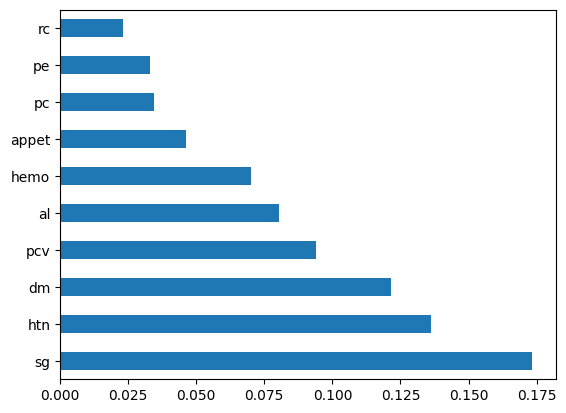

In [ ]:
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

In [ ]:
selected = ['rc', 'pe', 'pc', 'appet', 'hemo', 'al', 'pcv', 'dm', 'sg', 'htn']
unselected = list(set(X.columns) - set(selected))

X_selected = X.drop(unselected, axis = 1)

In [ ]:
X_selected

,sg,al,pc,hemo,pcv,rc,htn,dm,appet,pe
0,0.75,0.2,0.0,0.836735,0.777778,0.525424,1.0,1.0,0.0,0.0
1,0.75,0.8,0.0,0.557823,0.644444,0.525424,0.0,0.0,0.0,0.0
2,0.25,0.4,0.0,0.442177,0.488889,0.525424,0.0,1.0,1.0,0.0
3,0.00,0.8,1.0,0.551020,0.511111,0.305085,1.0,0.0,1.0,1.0
4,0.25,0.4,0.0,0.578231,0.577778,0.423729,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
395,0.75,0.0,0.0,0.857143,0.844444,0.474576,0.0,0.0,0.0,0.0
396,1.00,0.0,0.0,0.911565,1.000000,0.694915,0.0,0.0,0.0,0.0
397,0.75,0.0,0.0,0.863946,0.888889,0.559322,0.0,0.0,0.0,0.0
398,1.00,0.0,0.0,0.755102,0.933333,0.644068,0.0,0.0,0.0,0.0


#Splitting data

In [ ]:
X_train, X_valtest, y_train, y_valtest = train_test_split(X_selected, y, test_size = 0.2, random_state = 42)
X_val, X_test, y_val, y_test = train_test_split(X_valtest, y_valtest, test_size = 0.5, random_state = 42)

In [ ]:
print('X train shape: ',X_train.shape)
print('y train shape: ',y_test.shape)
print('X validation shape: ',X_val.shape)
print('y validation shape: ',y_val.shape)
print('X test shape: ',X_test.shape)
print('y test shape: ',y_train.shape)

X train shape:  (320, 10)
y train shape:  (40,)
X validation shape:  (40, 10)
y validation shape:  (40,)
X test shape:  (40, 10)
y test shape:  (320,)


# Membuat Model

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape = (X_selected.shape[1],)),
    tf.keras.layers.Dense(10, activation = 'relu'),
    tf.keras.layers.Dense(5, activation = 'relu'),
    tf.keras.layers.Dense(1, activation = 'sigmoid')
])

opt = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(optimizer = opt, loss = 'binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 10)                0         
                                                                 
 dense (Dense)               (None, 10)                110       
                                                                 
 dense_1 (Dense)             (None, 5)                 55        
                                                                 
 dense_2 (Dense)             (None, 1)                 6         
                                                                 
Total params: 171
Trainable params: 171
Non-trainable params: 0
_________________________________________________________________


# Train Model

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(patience=5, monitor='val_loss',
                                              restore_best_weights=True,
                                              verbose=1)

history_ann_class = model.fit(X_train, y_train,
                              validation_data=(X_val, y_val),
                              epochs=50, batch_size=32,
                              callbacks=[early_stop])

Epoch 1/50
10/10 [==============================] - 1s 35ms/step - loss: 0.7772 - accuracy: 0.3812 - val_loss: 0.8214 - val_accuracy: 0.3000
Epoch 2/50
10/10 [==============================] - 0s 6ms/step - loss: 0.7394 - accuracy: 0.3844 - val_loss: 0.7804 - val_accuracy: 0.3250
Epoch 3/50
10/10 [==============================] - 0s 6ms/step - loss: 0.7096 - accuracy: 0.3844 - val_loss: 0.7476 - val_accuracy: 0.3500
Epoch 4/50
10/10 [==============================] - 0s 6ms/step - loss: 0.6858 - accuracy: 0.4062 - val_loss: 0.7206 - val_accuracy: 0.4500
Epoch 5/50
10/10 [==============================] - 0s 7ms/step - loss: 0.6666 - accuracy: 0.4844 - val_loss: 0.6971 - val_accuracy: 0.5250
Epoch 6/50
10/10 [==============================] - 0s 8ms/step - loss: 0.6501 - accuracy: 0.5813 - val_loss: 0.6754 - val_accuracy: 0.6500
Epoch 7/50
10/10 [==============================] - 0s 7ms/step - loss: 0.6347 - accuracy: 0.6406 - val_loss: 0.6552 - val_accuracy: 0.6500
Epoch 8/50
10/10 [=

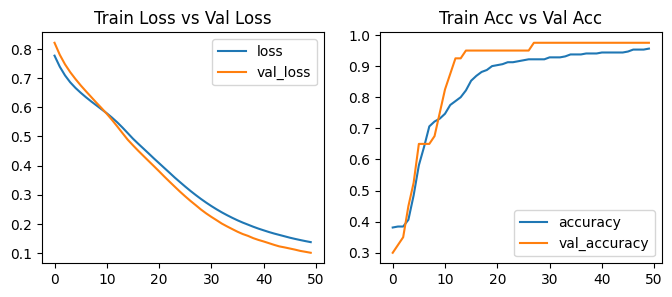

In [ ]:
loss = history_ann_class.history['loss']
val_loss = history_ann_class.history['val_loss']
accuracy = history_ann_class.history['accuracy']
val_accuracy = history_ann_class.history['val_accuracy']
epochs = range(len(loss))

fig, ax = plt.subplots(1, 2, figsize=(8,3))
ax[0].plot(epochs, loss)
ax[0].plot(epochs, val_loss)
ax[0].legend(['loss', 'val_loss'], loc='upper right')
ax[0].set_title('Train Loss vs Val Loss')
ax[1].plot(epochs, accuracy)
ax[1].plot(epochs, val_accuracy)
ax[1].legend(['accuracy', 'val_accuracy'], loc='lower right')
ax[1].set_title('Train Acc vs Val Acc')
plt.show()

# Evaluasi Model

In [ ]:
model.evaluate(X_test, y_test)

2/2 [==============================] - 0s 13ms/step - loss: 0.1226 - accuracy: 0.9500


[0.1226055845618248, 0.949999988079071]

2/2 [==============================] - 0s 9ms/step
              precision    recall  f1-score   support

           0       0.89      1.00      0.94        16
           1       1.00      0.92      0.96        24

    accuracy                           0.95        40
   macro avg       0.94      0.96      0.95        40
weighted avg       0.96      0.95      0.95        40



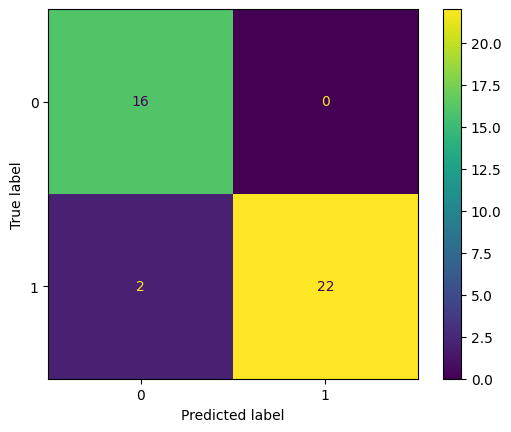

In [ ]:
#mencoba prediksi dengan menggunakan model
prob = model.predict(X_test) # probabilitas pasien mengidap ckd
y_pred = np.round(prob)
#probabilitas tersebut dibulatkan sehingga:
# y_pred = 1 berarti ckd dan y_pred = 0 berarti notckd

# confusion matrix
confmat = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confmat).plot()

#classification report
print(classification_report(y_test, y_pred))